# Chapter 18: Concurrency Control


## Core Question

How can a DBMS decide whether a read or write may proceed when several transactions
access the same data at the same time?

Chapter 18 and Chapter 19 share one class meeting. The classroom core is limited to
shared and exclusive locks, grant-or-wait decisions, wait-for graphs, and deadlock
detection. Detailed two-phase-locking variants, multiversion schemes, snapshot isolation,
and write skew are extensions.


## Connection to Other Chapters

Chapter 17 used conflicts and precedence graphs to judge completed schedules. This
chapter introduces rules that control operations while transactions are running.
Chapter 19 then explains how log records support recovery after an abort or crash.


## Prerequisites

You should be able to read schedule notation such as `r1(A)`, `w2(B)`, and `c1`, and
recognize a cycle in a small directed graph.


## Learning Objectives

After completing the classroom core, you should be able to:

1. Use an S/X compatibility matrix to decide whether a lock request is granted or waits.
2. Explain why a waiting transaction depends on an incompatible lock holder.
3. Build a wait-for graph from blocked requests.
4. Detect a deadlock cycle and explain why a victim transaction must be rolled back.
5. State the main limitation of the supplied lock simulator.


## Teaching Summary

| Classroom topic | Worked evidence | Evidence to retain |
|---|---|---|
| S/X compatibility | Two readers and one writer | Grant/wait decisions with reasons |
| Wait-for graph | Two transactions waiting in opposite order | Directed graph and cycle |
| Deadlock response | Victim rollback | Explanation of released locks and retry risk |


## 1. Shared and Exclusive Locks

A transaction must obtain an appropriate lock before accessing a protected item. An
incompatible request waits until the conflicting holder releases its lock.

- A **shared lock (S)** permits reading.
- An **exclusive lock (X)** permits reading and writing.


### Another reader can proceed; a writer must wait

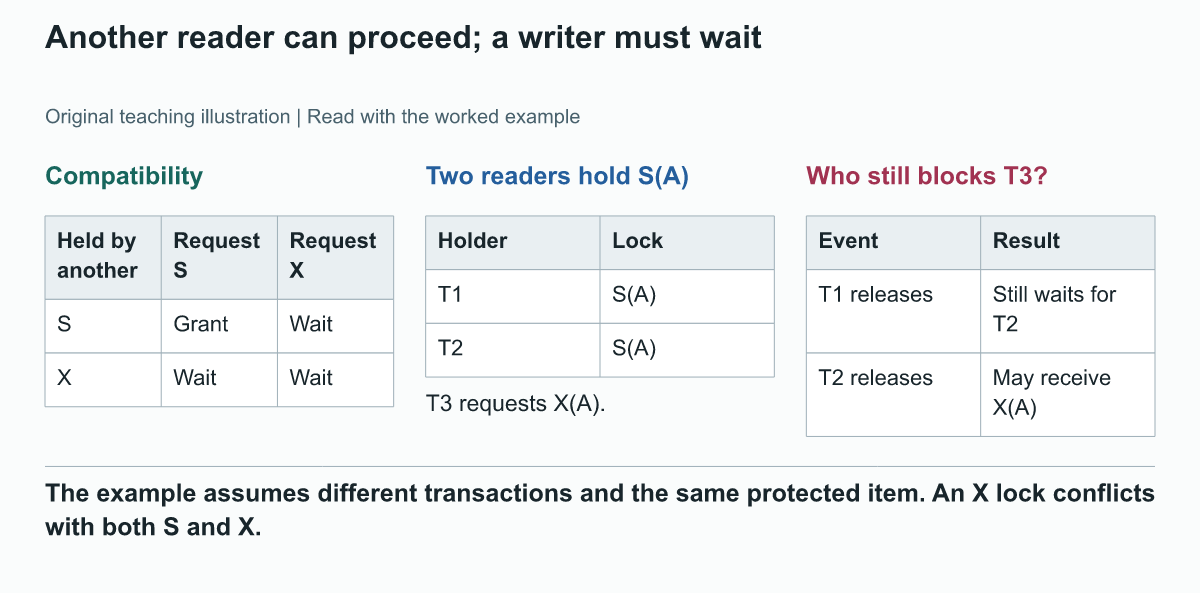

The example assumes different transactions and the same protected item. An X lock conflicts with both S and X.


### Compatibility Matrix

| Existing lock held by another transaction | Request S | Request X |
|---|---:|---:|
| S | grant | wait |
| X | wait | wait |

Multiple readers can hold `S` on the same item. Any pair involving an `X` lock held by a
different transaction is incompatible.


### Worked Example

```text
1. T1 requests S(A) -> grant
2. T2 requests S(A) -> grant
3. T3 requests X(A) -> wait for T1 and T2
4. T1 releases S(A) -> T3 still waits for T2
5. T2 releases S(A) -> T3 may receive X(A)
```

The writer cannot proceed after Step 4 because one incompatible holder remains.


### Predict Before Checking

Current locks are `T1:S(A)`, `T2:S(A)`, and `T3:X(B)`. Decide whether each request is
granted or waits:

1. `T4:S(A)`
2. `T4:X(A)`
3. `T4:S(B)`
4. `T4:X(C)`, where C has no holder


### Check Criteria

The decisions are grant, wait, wait, and grant. For every decision, identify the holder,
item, and compatibility-matrix entry.


## 2. Wait-For Graphs and Deadlock

A deadlock occurs when transactions wait in a cycle and none of them can continue.

```text
1. T1 receives X(A)
2. T2 receives X(B)
3. T1 requests X(B) -> waits for T2
4. T2 requests X(A) -> waits for T1
```

In a wait-for graph, each vertex is a transaction. Draw `Ti -> Tj` when `Ti` is waiting
for `Tj` to release an incompatible lock.

```text
T1 -> T2
T2 -> T1
```

The cycle indicates a deadlock in the current wait-for graph. This edge direction is
different from the conflict-order meaning used in a Chapter 17 precedence graph.


### A wait-for graph points from waiter to holder

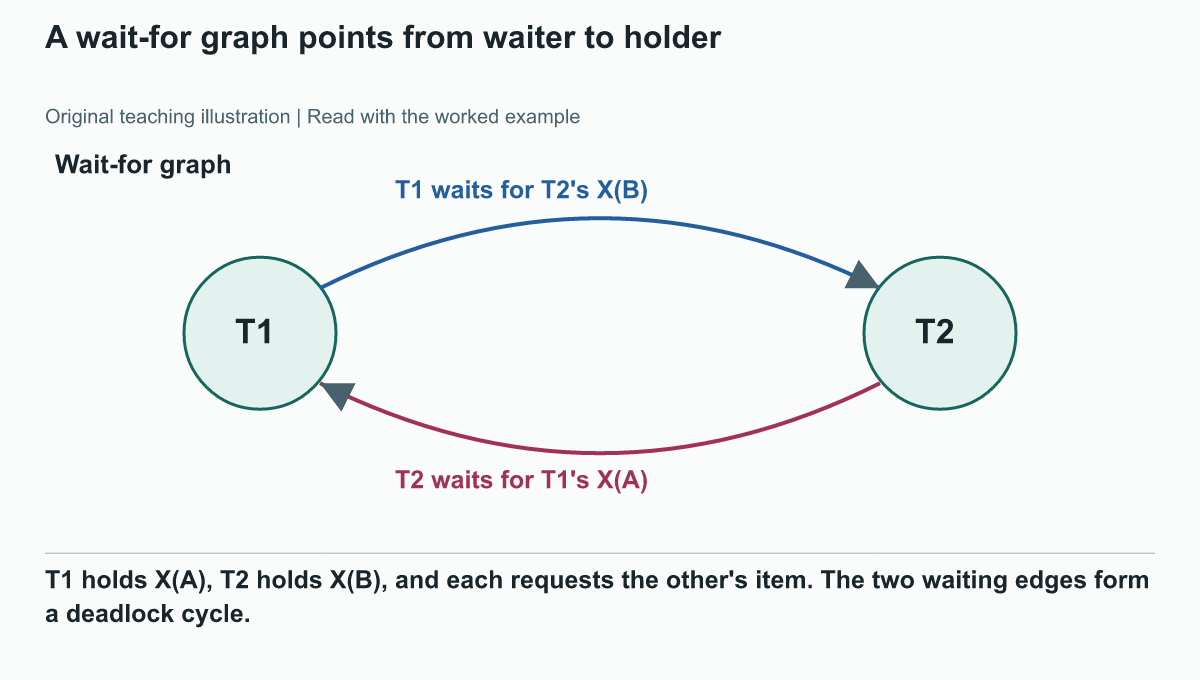

T1 holds X(A), T2 holds X(B), and each requests the other's item. The two waiting edges form a deadlock cycle.


### Practice

Given the edges `T1->T2`, `T2->T3`, `T3->T1`, and `T4->T2`:

1. Identify the transactions in the deadlock cycle.
2. Decide whether rolling back T4 breaks that cycle.
3. Explain what must be recomputed after T2 is rolled back and releases its locks.


### Check Criteria

T1, T2, and T3 form the cycle. T4 is not in that cycle, so rolling back T4 does not break
it. Rolling back T2 removes or changes waits involving locks held or requested by T2, and
the graph must be rebuilt from the remaining lock state.


## 3. Responding to Deadlock

Common approaches include:

- **Prevention:** restrict lock acquisition so a cycle cannot form, for example by using
  a common item order.
- **Detection and recovery:** allow waiting, detect a cycle, then roll back a victim.
- **Timeout:** roll back a transaction after a waiting threshold.

A timeout does not prove that a deadlock existed. A valid transaction may simply have
waited a long time. Victim selection may consider completed work, held locks, rollback
effects, and how often a transaction has already been selected. Repeatedly selecting the
same victim can cause starvation.


### Worked Example

If every transaction must request A before B, one transaction cannot hold B while waiting
for A as another holds A while waiting for B. The common order prevents that particular
cycle, although it may reduce flexibility or require advance knowledge of the access set.


### Discussion

When an API receives a deadlock-victim error, should it retry automatically? A complete
answer must consider whether the transaction is safe to repeat, whether an external side
effect could be duplicated, maximum retries, backoff, logging, and final failure handling.


## 4. Executable Activity

Predict each outcome before running:

```powershell
Run the embedded lock-simulator cell below.
```

| Scenario | Main expected observation |
|---|---|
| `compatible_reads` | T1 and T2 both receive S(A) |
| `writer_waits` | T2 waits for X(A) until T1 commits |
| `deadlock` | Edges `T1->T2` and `T2->T1` form a cycle |
| `violates_two_phase` | `two_phase=false` |
| `basic_two_phase_not_strict` | `two_phase=true`, `strict_two_phase=false` |

The classroom evidence focuses on the first three scenarios. The final two support the
extension section.

The simulator models S/X compatibility, a simplified FIFO waiting rule, selected lock
release rules, and wait-for graphs. It does not implement lock upgrades, multiple
granularity, predicate locks, a production DBMS scheduler, SQL semantics, or crash
recovery. Its output is teaching-model evidence, not a measurement of a specific DBMS.


## Extension: Two-Phase Locking

Basic two-phase locking separates lock use into a growing phase, in which locks may be
acquired but not released, and a shrinking phase, in which locks may be released but no
new lock may be acquired.

```text
Legal basic 2PL:
lock-X(A), lock-S(B), unlock(A), unlock(B), commit

Violation:
lock-S(A), unlock(A), lock-X(B), commit
```

The second sequence requests a new lock after the shrinking phase begins. Basic 2PL
supports conflict serializability but can still deadlock. Strict 2PL retains exclusive
locks until commit or abort, which prevents other transactions from reading or
overwriting uncommitted writes. Detailed protocol proofs and rigorous 2PL are not part of
the Exam 3 classroom core.


## Extension: Multiversion and Snapshot Concepts

Multiversion systems retain several committed versions so a reader may use a version
visible to its snapshot. This can reduce reader-writer blocking, but correctness depends
on version-selection and validation rules.

Snapshot isolation is not automatically serializable. Two transactions can read the
same condition, update different rows, and jointly violate a constraint without a direct
write-write conflict. The supplied the embedded multiversion demonstration demonstrates this write-skew pattern as
a model. It is not a test of a production DBMS implementation.


## Common Errors

1. Claiming that only one reader can hold an S lock.
2. Claiming that an X lock blocks only writers.
3. Treating one wait edge as a deadlock without finding a cycle.
4. Confusing wait-for graph direction with precedence graph direction.
5. Assuming that a timeout proves deadlock.
6. Assuming that basic two-phase locking cannot deadlock.
7. Treating the simulator as production DBMS behavior.


## Individual Learning Evidence

Retain:

1. A completed S/X compatibility matrix with reasons.
2. The four grant-or-wait decisions.
3. One wait-for graph, its cycle, and a victim explanation.
4. Output from the first three lock-simulator scenarios.
5. One explicit simulator limitation.

Extension work may include a two-phase-locking sequence and the multiversion demo, but it
is not required for the Exam 3 classroom core.


## Chapter Summary

S/S requests from different transactions are compatible; any pair involving X is not.
A wait-for edge points from a waiting transaction to an incompatible holder, and a cycle
indicates deadlock. Deadlock handling must consider rollback effects and retry safety.
Chapter 19 connects transaction failure to log-based recovery.


## After-Class Continuation

Add a three-transaction scenario that contains two levels of waiting but no cycle. Draw
the graph before running the simulator. Study two-phase-locking variants, multiversion
visibility, snapshot isolation, and write skew as extensions.


## Why This Chapter Uses a Simulation

SQLite can create tables and execute transactions, but it does not expose a server lock manager, wait-for graph, write-ahead log, or restart-recovery procedure for direct classroom inspection. This notebook therefore uses a small verified Python simulation for the chapter mechanism. Treat the result as an instructional model, not as observed SQLite server behavior.


## Executable Notebook Demonstrations

The source code and data are embedded in this notebook. Each cell creates a temporary directory, runs the demonstration, and removes the temporary files automatically.


### Lock simulator


In [1]:
import subprocess
import sys
import tempfile
from pathlib import Path

SCRIPT_SOURCE = '''"""Simulate small S/X lock schedules for Chapter 18 activities."""

from __future__ import annotations

import argparse
import json
from collections import defaultdict
from pathlib import Path
from typing import Any


def compatible(left: str, right: str) -> bool:
    return left == "S" and right == "S"


def cycle_nodes(edges: set[tuple[str, str]]) -> list[str] | None:
    graph: dict[str, list[str]] = defaultdict(list)
    nodes: set[str] = set()
    for source, target in edges:
        graph[source].append(target)
        nodes.update({source, target})

    state: dict[str, int] = {node: 0 for node in nodes}
    stack: list[str] = []

    def visit(node: str) -> list[str] | None:
        state[node] = 1
        stack.append(node)
        for target in sorted(graph[node]):
            if state[target] == 0:
                found = visit(target)
                if found is not None:
                    return found
            elif state[target] == 1:
                start = stack.index(target)
                return stack[start:] + [target]
        stack.pop()
        state[node] = 2
        return None

    for node in sorted(nodes):
        if state[node] == 0:
            found = visit(node)
            if found is not None:
                return found
    return None


class LockSimulation:
    def __init__(self) -> None:
        self.held: dict[str, list[tuple[str, str]]] = defaultdict(list)
        self.waiting: list[tuple[str, str, str]] = []
        self.released: set[str] = set()
        self.two_phase = True
        self.strict_two_phase = True
        self.events: list[str] = []

    def blockers(self, transaction: str, mode: str, item: str) -> list[str]:
        return sorted(
            holder
            for holder, held_mode in self.held[item]
            if holder != transaction and not compatible(mode, held_mode)
        )

    def request(self, transaction: str, mode: str, item: str) -> None:
        if transaction in self.released:
            self.two_phase = False
        blockers = self.blockers(transaction, mode, item)
        if blockers:
            self.waiting.append((transaction, mode, item))
            self.events.append(
                f"WAIT {transaction} {mode}({item}) for {','.join(blockers)}"
            )
        else:
            self.held[item].append((transaction, mode))
            self.events.append(f"GRANT {transaction} {mode}({item})")

    def unlock(self, transaction: str, item: str, ending: bool = False) -> None:
        released_modes = [
            mode for holder, mode in self.held[item] if holder == transaction
        ]
        if not ending and "X" in released_modes:
            self.strict_two_phase = False
        self.held[item] = [
            (holder, mode)
            for holder, mode in self.held[item]
            if holder != transaction
        ]
        self.released.add(transaction)
        self.events.append(f"RELEASE {transaction} ({item})")
        self.grant_waiting()

    def grant_waiting(self) -> None:
        progress = True
        while progress:
            progress = False
            remaining: list[tuple[str, str, str]] = []
            for transaction, mode, item in self.waiting:
                if not self.blockers(transaction, mode, item):
                    self.held[item].append((transaction, mode))
                    self.events.append(f"GRANT-WAITING {transaction} {mode}({item})")
                    progress = True
                else:
                    remaining.append((transaction, mode, item))
            self.waiting = remaining

    def finish(self, transaction: str, action: str) -> None:
        items = [
            item
            for item, locks in self.held.items()
            if any(holder == transaction for holder, _mode in locks)
        ]
        self.waiting = [entry for entry in self.waiting if entry[0] != transaction]
        self.events.append(f"{action} {transaction}")
        for item in items:
            self.unlock(transaction, item, ending=True)

    def wait_edges(self) -> set[tuple[str, str]]:
        edges: set[tuple[str, str]] = set()
        for transaction, mode, item in self.waiting:
            for blocker in self.blockers(transaction, mode, item):
                edges.add((transaction, blocker))
        return edges

    def run(self, actions: list[dict[str, str]]) -> dict[str, Any]:
        for step in actions:
            transaction = step["transaction"]
            action = step["action"]
            if action == "LOCK":
                self.request(transaction, step["mode"], step["item"])
            elif action == "UNLOCK":
                self.unlock(transaction, step["item"])
            elif action in {"COMMIT", "ABORT"}:
                self.finish(transaction, action)
            else:
                raise ValueError(f"Unknown action: {action}")

        edges = self.wait_edges()
        cycle = cycle_nodes(edges)
        return {
            "events": self.events,
            "two_phase": self.two_phase,
            "strict_two_phase": self.two_phase and self.strict_two_phase,
            "wait_edges": sorted(f"{source}->{target}" for source, target in edges),
            "deadlock_cycle": cycle,
        }


def analyze(actions: list[dict[str, str]]) -> dict[str, Any]:
    return LockSimulation().run(actions)


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "scenario_file",
        nargs="?",
        type=Path,
        default=Path(__file__).with_name("lock_scenarios.json"),
    )
    args = parser.parse_args()
    scenarios = json.loads(args.scenario_file.read_text(encoding="utf-8"))
    for name, actions in scenarios.items():
        print(f"[{name}]")
        print(json.dumps(analyze(actions), ensure_ascii=False, sort_keys=True))


if __name__ == "__main__":
    main()
'''

DATA_1_SOURCE = """{
  "compatible_reads": [
    {"transaction": "T1", "action": "LOCK", "mode": "S", "item": "A"},
    {"transaction": "T2", "action": "LOCK", "mode": "S", "item": "A"},
    {"transaction": "T1", "action": "COMMIT"},
    {"transaction": "T2", "action": "COMMIT"}
  ],
  "writer_waits": [
    {"transaction": "T1", "action": "LOCK", "mode": "S", "item": "A"},
    {"transaction": "T2", "action": "LOCK", "mode": "X", "item": "A"},
    {"transaction": "T1", "action": "COMMIT"},
    {"transaction": "T2", "action": "COMMIT"}
  ],
  "deadlock": [
    {"transaction": "T1", "action": "LOCK", "mode": "X", "item": "A"},
    {"transaction": "T2", "action": "LOCK", "mode": "X", "item": "B"},
    {"transaction": "T1", "action": "LOCK", "mode": "X", "item": "B"},
    {"transaction": "T2", "action": "LOCK", "mode": "X", "item": "A"}
  ],
  "violates_two_phase": [
    {"transaction": "T1", "action": "LOCK", "mode": "S", "item": "A"},
    {"transaction": "T1", "action": "UNLOCK", "item": "A"},
    {"transaction": "T1", "action": "LOCK", "mode": "X", "item": "B"},
    {"transaction": "T1", "action": "COMMIT"}
  ],
  "basic_two_phase_not_strict": [
    {"transaction": "T1", "action": "LOCK", "mode": "X", "item": "A"},
    {"transaction": "T1", "action": "LOCK", "mode": "S", "item": "B"},
    {"transaction": "T1", "action": "UNLOCK", "item": "A"},
    {"transaction": "T1", "action": "UNLOCK", "item": "B"},
    {"transaction": "T1", "action": "COMMIT"}
  ]
}
"""

embedded_files = {
    'lock_simulator.py': SCRIPT_SOURCE,
    'lock_scenarios.json': DATA_1_SOURCE,
}
with tempfile.TemporaryDirectory(prefix="database_notebook_") as temp_directory:
    temp_path = Path(temp_directory)
    for filename, content in embedded_files.items():
        (temp_path / filename).write_text(content, encoding="utf-8")
    command = [sys.executable, str(temp_path / 'lock_simulator.py')] + ['lock_scenarios.json']
    completed = subprocess.run(command, cwd=temp_path, text=True, capture_output=True, check=False)
    print(completed.stdout, end="")
    if completed.stderr:
        print(completed.stderr, end="", file=sys.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Embedded program failed with exit code {completed.returncode}")


[compatible_reads]
{"deadlock_cycle": null, "events": ["GRANT T1 S(A)", "GRANT T2 S(A)", "COMMIT T1", "RELEASE T1 (A)", "COMMIT T2", "RELEASE T2 (A)"], "strict_two_phase": true, "two_phase": true, "wait_edges": []}
[writer_waits]
{"deadlock_cycle": null, "events": ["GRANT T1 S(A)", "WAIT T2 X(A) for T1", "COMMIT T1", "RELEASE T1 (A)", "GRANT-WAITING T2 X(A)", "COMMIT T2", "RELEASE T2 (A)"], "strict_two_phase": true, "two_phase": true, "wait_edges": []}
[deadlock]
{"deadlock_cycle": ["T1", "T2", "T1"], "events": ["GRANT T1 X(A)", "GRANT T2 X(B)", "WAIT T1 X(B) for T2", "WAIT T2 X(A) for T1"], "strict_two_phase": true, "two_phase": true, "wait_edges": ["T1->T2", "T2->T1"]}
[violates_two_phase]
{"deadlock_cycle": null, "events": ["GRANT T1 S(A)", "RELEASE T1 (A)", "GRANT T1 X(B)", "COMMIT T1", "RELEASE T1 (B)"], "strict_two_phase": false, "two_phase": false, "wait_edges": []}
[basic_two_phase_not_strict]
{"deadlock_cycle": null, "events": ["GRANT T1 X(A)", "GRANT T1 S(B)", "RELEASE T1 (A)

### Multiversion demonstration


In [2]:
import subprocess
import sys
import tempfile
from pathlib import Path

SCRIPT_SOURCE = '''"""Demonstrate version visibility and snapshot write skew."""

from __future__ import annotations

import json
from typing import Any


def visible_version(
    versions: list[dict[str, int]], start_timestamp: int
) -> dict[str, int]:
    visible = [
        version
        for version in versions
        if version["commit_timestamp"] <= start_timestamp
    ]
    if not visible:
        raise ValueError("No committed version is visible")
    return max(visible, key=lambda version: version["commit_timestamp"])


def write_skew() -> dict[str, Any]:
    initial = {"checking": 100, "savings": 200}
    withdrawal = 200

    t1_snapshot = initial.copy()
    t2_snapshot = initial.copy()
    t1_allows = sum(t1_snapshot.values()) - withdrawal >= 0
    t2_allows = sum(t2_snapshot.values()) - withdrawal >= 0

    t1_write_set = {"checking"}
    t2_write_set = {"savings"}
    overlapping_writes = bool(t1_write_set & t2_write_set)

    final = initial.copy()
    if t1_allows:
        final["checking"] -= withdrawal
    if t2_allows:
        final["savings"] -= withdrawal

    return {
        "initial": initial,
        "t1_allows": t1_allows,
        "t2_allows": t2_allows,
        "overlapping_writes": overlapping_writes,
        "both_pass_write_write_check": t1_allows
        and t2_allows
        and not overlapping_writes,
        "final": final,
        "constraint_sum_nonnegative": sum(final.values()) >= 0,
    }


def demonstration() -> dict[str, Any]:
    versions = [
        {"commit_timestamp": 10, "value": 100},
        {"commit_timestamp": 20, "value": 90},
        {"commit_timestamp": 30, "value": 120},
    ]
    return {
        "versions": versions,
        "reader_at_15": visible_version(versions, 15),
        "reader_at_25": visible_version(versions, 25),
        "reader_at_35": visible_version(versions, 35),
        "write_skew": write_skew(),
    }


def main() -> None:
    print(json.dumps(demonstration(), ensure_ascii=False, indent=2, sort_keys=True))


if __name__ == "__main__":
    main()
'''

embedded_files = {
    'mvcc_demo.py': SCRIPT_SOURCE,
}
with tempfile.TemporaryDirectory(prefix="database_notebook_") as temp_directory:
    temp_path = Path(temp_directory)
    for filename, content in embedded_files.items():
        (temp_path / filename).write_text(content, encoding="utf-8")
    command = [sys.executable, str(temp_path / 'mvcc_demo.py')] + []
    completed = subprocess.run(command, cwd=temp_path, text=True, capture_output=True, check=False)
    print(completed.stdout, end="")
    if completed.stderr:
        print(completed.stderr, end="", file=sys.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Embedded program failed with exit code {completed.returncode}")


{
  "reader_at_15": {
    "commit_timestamp": 10,
    "value": 100
  },
  "reader_at_25": {
    "commit_timestamp": 20,
    "value": 90
  },
  "reader_at_35": {
    "commit_timestamp": 30,
    "value": 120
  },
  "versions": [
    {
      "commit_timestamp": 10,
      "value": 100
    },
    {
      "commit_timestamp": 20,
      "value": 90
    },
    {
      "commit_timestamp": 30,
      "value": 120
    }
  ],
  "write_skew": {
    "both_pass_write_write_check": true,
    "constraint_sum_nonnegative": false,
    "final": {
      "checking": -100,
      "savings": 0
    },
    "initial": {
      "checking": 100,
      "savings": 200
    },
    "overlapping_writes": false,
    "t1_allows": true,
    "t2_allows": true
  }
}
